# BSCS — Bhatbhateni Sales Cleaning & Solutions

**Dataset:** Bhatbhateni sales data for 2025  
**Purpose:** Clean the raw data, answer Q1–Q17, create visualisations, and build a simple predictive model.

This notebook is designed for **Visual Studio Code** with the Microsoft Python and Jupyter extensions.

## Step 1 — Load libraries (Q1)

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the project root whether VS Code starts the notebook from the root
# or from the notebooks folder.
CURRENT = Path.cwd()
PROJECT_ROOT = CURRENT if (CURRENT / 'data').exists() else CURRENT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

import bscs_analysis as bscs

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
print('Project root:', PROJECT_ROOT)

Project root: /mnt/data/BSCS_VSCode_Project


## Step 2 — Load dataset (Q2)

In [2]:
data_path = PROJECT_ROOT / 'data' / 'BSCS.csv'
df_raw = pd.read_csv(data_path)
print('Dataset loaded from:', data_path)

Dataset loaded from: /mnt/data/BSCS_VSCode_Project/data/BSCS.csv


## Step 3 — Inspect dataset (Q3)

In [3]:
display(df_raw.head())
print('Shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())

,TransactionID,Date,CustomerID,CustomerName,Branch,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod
0,TXN101590,2025-05-19,CUST1100,Sujan Shrestha,Pokhara - Lakeside,Bakery,Chocolate Cake Slice,2,171.29,342.58,Khalti
1,TXN103282,2025-03-07,CUST1005,Milan Lama,Butwal - Traffic Chowk,Personal Care,Dove Soap,3,149.59,448.77,eSewa
2,TXN103539,2025-10-05,CUST1130,Alina Rai,Bhaktapur - Suryabinayak,Apparel,Winter Jacket,4,"2,794.25","11,177.00",Khalti
3,TXN102479,2025-11-12,CUST1057,Neha Karki,Kathmandu - New Road,Household,Surf Excel 1kg,4,399.62,"1,598.48",Cash
4,TXN104408,2025-10-09,CUST1005,Milan Lama,Butwal - Traffic Chowk,Beverages,Gorkha Beer (6-pack),2,281.01,562.02,eSewa


Shape: (18812, 11)
Columns: ['TransactionID', 'Date', 'CustomerID', 'CustomerName', 'Branch', 'ProductCategory', 'ProductName', 'Quantity', 'UnitPrice', 'TotalAmount', 'PaymentMethod']


## Step 4 — Data types and numeric summary (Q4)

In [4]:
print(df_raw.dtypes)
display(df_raw[['Quantity', 'UnitPrice', 'TotalAmount']].describe().round(2))

TransactionID       object
Date                object
CustomerID          object
CustomerName        object
Branch              object
ProductCategory     object
ProductName         object
Quantity             int64
UnitPrice          float64
TotalAmount        float64
PaymentMethod       object
dtype: object


,Quantity,UnitPrice,TotalAmount
count,"18,812.00","18,441.00","18,812.00"
mean,2.51,728.80,"1,819.99"
std,1.11,766.35,"2,241.97"
min,1.00,40.14,40.61
25%,2.00,240.16,488.40
50%,3.00,416.78,989.00
75%,3.00,848.32,"2,142.54"
max,4.00,"3,499.28","13,997.12"


## Step 5 — Detect data-quality issues (Q5)

In [5]:
missing = pd.DataFrame({
    'MissingCount': df_raw.isna().sum(),
    'MissingPercent': (df_raw.isna().mean() * 100).round(2)
})
display(missing[missing['MissingCount'] > 0])
print('Exact duplicate rows:', df_raw.duplicated().sum())
print('Unique TransactionID values:', df_raw['TransactionID'].nunique())
print('Transaction IDs containing multiple rows:', (df_raw.groupby('TransactionID').size() > 1).sum())

available_price = df_raw['UnitPrice'].notna()
mismatch = (
    df_raw.loc[available_price, 'TotalAmount']
    - df_raw.loc[available_price, 'Quantity'] * df_raw.loc[available_price, 'UnitPrice']
).abs() > 0.01
print('Illogical totals among rows with available prices:', mismatch.sum())

,MissingCount,MissingPercent
CustomerName,568,3.02
ProductCategory,282,1.50
UnitPrice,371,1.97
PaymentMethod,468,2.49


Exact duplicate rows: 724
Unique TransactionID values: 6000
Transaction IDs containing multiple rows: 4860
Illogical totals among rows with available prices: 0


### Duplicate interpretation

A repeated `TransactionID` is not automatically a duplicate because one shopping basket can contain several products. Only rows that are identical across all columns should be removed.

## Steps 6–8 — Clean data and engineer features

In [6]:
df, cleaning_summary = bscs.clean_data(df_raw)
print(json.dumps(cleaning_summary, indent=2))
display(df.head())
print('Final missing values:', df.isna().sum().sum())

{
  "raw_rows": 18812,
  "raw_columns": 11,
  "exact_duplicate_rows": 724,
  "rows_after_duplicate_removal": 18088,
  "rows_removed": 724,
  "unique_transaction_ids": 6000,
  "multi_line_transaction_ids": 4823,
  "maximum_lines_in_one_transaction": 5,
  "total_mismatches_before_correction": 0,
  "remaining_missing_values": 0
}


,TransactionID,Date,CustomerID,CustomerName,Branch,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod,CustomerNameWasMissing,ProductCategoryWasMissing,UnitPriceWasMissing,PaymentMethodWasMissing,Year,Month,MonthName,YearMonth,DayOfWeek,DayNumber,IsWeekend,City,CalculatedTotal,TotalDifference
0,TXN101590,2025-05-19,CUST1100,Sujan Shrestha,Pokhara - Lakeside,Bakery,Chocolate Cake Slice,2,171.29,342.58,Khalti,False,False,False,False,2025,5,May,2025-05,Monday,0,False,Pokhara,342.58,0.00
1,TXN103282,2025-03-07,CUST1005,Milan Lama,Butwal - Traffic Chowk,Personal Care,Dove Soap,3,149.59,448.77,eSewa,False,False,False,False,2025,3,March,2025-03,Friday,4,False,Butwal,448.77,0.00
2,TXN103539,2025-10-05,CUST1130,Alina Rai,Bhaktapur - Suryabinayak,Apparel,Winter Jacket,4,"2,794.25","11,177.00",Khalti,False,False,False,False,2025,10,October,2025-10,Sunday,6,True,Bhaktapur,"11,177.00",0.00
3,TXN102479,2025-11-12,CUST1057,Neha Karki,Kathmandu - New Road,Household,Surf Excel 1kg,4,399.62,"1,598.48",Cash,False,False,False,False,2025,11,November,2025-11,Wednesday,2,False,Kathmandu,"1,598.48",0.00
4,TXN104408,2025-10-09,CUST1005,Milan Lama,Butwal - Traffic Chowk,Beverages,Gorkha Beer (6-pack),2,281.01,562.02,eSewa,False,False,False,False,2025,10,October,2025-10,Thursday,3,False,Butwal,562.02,0.00


Final missing values: 0


### Cleaning rules used

- Exact duplicates: removed with `drop_duplicates()`.
- `CustomerName`: filled from the stable `CustomerID → CustomerName` mapping.
- `ProductCategory`: filled from the stable `ProductName → ProductCategory` mapping.
- `UnitPrice`: recovered from `TotalAmount / Quantity`, with median fallbacks.
- `PaymentMethod`: labelled `Unknown` to retain valid revenue.
- `Date`: converted to datetime; year, month, weekday, weekend, and city features added.
- `TotalAmount`: checked against `Quantity × UnitPrice`.

## Steps 9–15 — Analysis tables

In [7]:
tables = bscs.build_analysis_tables(df)
print('Available tables:')
print(list(tables.keys()))

Available tables:
['category_summary', 'branch_summary', 'city_summary', 'payment_summary', 'payment_branch_counts', 'payment_branch_share', 'monthly_revenue', 'day_revenue', 'weekend_weekday', 'product_quantity', 'product_revenue', 'customer_summary', 'correlation', 'line_outliers', 'basket_values', 'basket_outliers', 'outlier_thresholds']


### Q9 — Univariate analysis

In [8]:
display(tables['category_summary'])
display(tables['branch_summary'][['Branch', 'LineItems', 'Revenue']])
display(tables['payment_summary'])
print('TotalAmount skewness:', round(df['TotalAmount'].skew(), 3))

,ProductCategory,LineItems,UniqueTransactions,QuantitySold,Revenue,LineItemSharePercent,RevenueSharePercent
0,Electronics,2186,1914,5476,"10,419,134.62",12.09,31.57
1,Apparel,2188,1935,5527,"9,251,535.64",12.10,28.03
2,Grocery,3065,2519,7690,"3,943,021.00",16.94,11.95
3,Household,2212,1907,5559,"3,620,342.47",12.23,10.97
4,Personal Care,2246,1959,5581,"2,064,900.31",12.42,6.26
5,Beverages,2179,1894,5527,"1,558,152.52",12.05,4.72
6,Dairy,2217,1925,5508,"1,260,518.61",12.26,3.82
7,Bakery,1795,1618,4449,"886,540.47",9.92,2.69


,Branch,LineItems,Revenue
0,Kathmandu - Kupondole,3241,"5,988,126.62"
1,Bhaktapur - Suryabinayak,3050,"5,597,500.45"
2,Butwal - Traffic Chowk,2940,"5,448,358.25"
3,Kathmandu - New Road,2561,"4,641,030.50"
4,Lalitpur - Pulchowk,2337,"4,173,146.13"
5,Pokhara - Lakeside,1957,"3,494,044.41"
6,Chitwan - Bharatpur,1063,"1,994,033.40"
7,Biratnagar - Main Road,939,"1,667,905.88"


,PaymentMethod,LineItems,Revenue,AverageLineValue,MedianLineValue,UsageSharePercent
0,Cash,6218,"11,120,537.92","1,788.44",980.28,34.38
1,eSewa,4951,"8,988,938.00","1,815.58",994.48,27.37
2,Khalti,3795,"7,139,783.41","1,881.37",995.58,20.98
3,Debit/Credit Card,1813,"3,298,721.73","1,819.48",996.60,10.02
4,Bank Transfer,859,"1,588,868.53","1,849.67",991.44,4.75
5,Unknown,452,"867,296.05","1,918.80","1,076.79",2.50


TotalAmount skewness: 2.464


### Q10 — Monthly, weekend, and day-of-week trends

In [9]:
display(tables['monthly_revenue'])
display(tables['weekend_weekday'])
display(tables['day_revenue'].sort_values('Revenue', ascending=False))

,YearMonth,Revenue,MoMChangePercent
0,2025-01,"2,047,697.10",NaN
1,2025-02,"1,813,821.23",-11.42
2,2025-03,"1,887,644.85",4.07
3,2025-04,"3,088,404.52",63.61
4,2025-05,"1,804,819.74",-41.56
5,2025-06,"1,875,854.82",3.94
6,2025-07,"1,881,584.08",0.31
7,2025-08,"2,096,176.94",11.40
8,2025-09,"4,630,698.52",120.91
9,2025-10,"4,717,670.71",1.88


,DayType,NumberOfDays,TotalRevenue,AverageDailyRevenue,MedianDailyRevenue
0,Weekday,261,"23,705,495.89","90,825.65","78,423.56"
1,Weekend,104,"9,298,649.75","89,410.09","78,219.73"


,DayOfWeek,Revenue
3,Thursday,"4,876,393.65"
2,Wednesday,"4,874,642.96"
1,Tuesday,"4,836,536.99"
0,Monday,"4,826,070.64"
6,Sunday,"4,823,893.16"
5,Saturday,"4,474,756.59"
4,Friday,"4,291,851.65"


### Q11 — Branch and city performance

In [10]:
display(tables['branch_summary'])
display(tables['city_summary'])

,Branch,LineItems,UniqueTransactions,Revenue,Transactions,AverageTransactionValue,MedianTransactionValue
0,Kathmandu - Kupondole,3241,1047,"5,988,126.62",1047,"5,719.32","4,472.46"
1,Bhaktapur - Suryabinayak,3050,1017,"5,597,500.45",1017,"5,503.93","4,089.15"
2,Butwal - Traffic Chowk,2940,985,"5,448,358.25",985,"5,531.33","4,278.91"
3,Kathmandu - New Road,2561,842,"4,641,030.50",842,"5,511.91","4,345.93"
4,Lalitpur - Pulchowk,2337,766,"4,173,146.13",766,"5,447.97","4,201.93"
5,Pokhara - Lakeside,1957,659,"3,494,044.41",659,"5,302.04","4,245.02"
6,Chitwan - Bharatpur,1063,356,"1,994,033.40",356,"5,601.22","4,254.31"
7,Biratnagar - Main Road,939,328,"1,667,905.88",328,"5,085.08","3,727.78"


,City,LineItems,UniqueTransactions,Revenue
0,Kathmandu,5802,1889,"10,629,157.12"
1,Bhaktapur,3050,1017,"5,597,500.45"
2,Butwal,2940,985,"5,448,358.25"
3,Lalitpur,2337,766,"4,173,146.13"
4,Pokhara,1957,659,"3,494,044.41"
5,Chitwan,1063,356,"1,994,033.40"
6,Biratnagar,939,328,"1,667,905.88"


### Q12 — Product and category performance

In [11]:
print('Top 10 products by quantity:')
display(tables['product_quantity'].head(10))
print('Top 10 products by revenue:')
display(tables['product_revenue'].head(10))

Top 10 products by quantity:


,ProductName,QuantitySold,Revenue
37,Wall Clock,1215,"2,459,453.52"
9,Dove Soap,1194,"450,788.55"
5,Coca-Cola 1.5L,1183,"333,597.45"
28,Sliced Bread,1174,"232,262.07"
10,Extension Board,1167,"2,155,259.21"
27,Sanitary Pads Pack,1163,"417,913.93"
22,Paneer 250g,1163,"265,362.45"
18,Mustard Oil 1L,1157,"595,810.58"
17,LED Bulb 9W,1150,"760,378.26"
8,DDC Milk 1L,1146,"256,849.14"


Top 10 products by revenue:


,ProductName,QuantitySold,Revenue
37,Wall Clock,1215,"2,459,453.52"
10,Extension Board,1167,"2,155,259.21"
23,Power Bank 10000mAh,1073,"1,977,709.90"
34,USB Cable Type-C,1031,"1,968,887.55"
16,Kids Frock,1124,"1,928,877.20"
1,Bluetooth Earphones,990,"1,857,824.44"
29,Socks (3-pair pack),1130,"1,855,597.09"
7,Cotton T-Shirt,1077,"1,854,507.38"
39,Winter Jacket,1127,"1,842,626.06"
11,Formal Shirt,1069,"1,769,927.91"


### Q13 — Customer analysis

In [12]:
display(tables['customer_summary'].head(10))
repeat_customers = (tables['customer_summary']['Transactions'] > 1).sum()
one_time_customers = (tables['customer_summary']['Transactions'] == 1).sum()
print('Repeat customers:', repeat_customers)
print('One-time customers:', one_time_customers)
print('Average total spend per customer:', round(tables['customer_summary']['TotalSpend'].mean(), 2))

,CustomerID,CustomerName,Transactions,LineItems,TotalSpend,AverageBasketValue
2,CUST1002,Kritika Bhattarai,221,661,"1,286,840.72","5,822.81"
25,CUST1025,Kiran Poudel,198,613,"1,097,045.67","5,540.63"
52,CUST1052,Aashish Poudel,200,615,"1,072,696.01","5,363.48"
146,CUST1149,Sarita Poudel,172,510,"947,133.89","5,506.59"
98,CUST1100,Sujan Shrestha,179,531,"920,019.05","5,139.77"
20,CUST1020,Deepak Magar,138,423,"782,933.61","5,673.43"
39,CUST1039,Sabina Thapa,152,429,"774,413.97","5,094.83"
61,CUST1061,Bikash Shrestha,144,429,"741,952.36","5,152.45"
3,CUST1003,Kiran Adhikari,123,406,"701,884.52","5,706.38"
116,CUST1118,Alina Shrestha,135,389,"690,781.19","5,116.90"


Repeat customers: 144
One-time customers: 3
Average total spend per customer: 224518.0


### Q14 — Payment-method analysis

In [13]:
display(tables['payment_branch_share'])
display(tables['payment_summary'].sort_values('AverageLineValue', ascending=False))

PaymentMethod,Bank Transfer,Cash,Debit/Credit Card,Khalti,Unknown,eSewa
Branch,,,,,,
Bhaktapur - Suryabinayak,4.79,34.59,10.72,20.85,2.33,26.72
Biratnagar - Main Road,5.01,33.44,9.48,21.83,2.45,27.80
Butwal - Traffic Chowk,5.03,35.92,9.35,19.97,2.35,27.38
Chitwan - Bharatpur,4.70,33.40,8.75,22.58,2.26,28.32
Kathmandu - Kupondole,4.88,33.35,10.27,21.57,2.53,27.40
Kathmandu - New Road,4.69,35.61,9.33,21.12,2.77,26.47
Lalitpur - Pulchowk,4.84,34.06,10.87,20.15,2.87,27.21
Pokhara - Lakeside,3.93,33.16,10.37,21.26,2.30,28.97


,PaymentMethod,LineItems,Revenue,AverageLineValue,MedianLineValue,UsageSharePercent
5,Unknown,452,"867,296.05","1,918.80","1,076.79",2.50
2,Khalti,3795,"7,139,783.41","1,881.37",995.58,20.98
4,Bank Transfer,859,"1,588,868.53","1,849.67",991.44,4.75
3,Debit/Credit Card,1813,"3,298,721.73","1,819.48",996.60,10.02
1,eSewa,4951,"8,988,938.00","1,815.58",994.48,27.37
0,Cash,6218,"11,120,537.92","1,788.44",980.28,34.38


**Interpretation note:** Payment methods vary across some rows sharing the same `TransactionID`, so payment analysis is performed at line-item level. This is a source-data limitation and should be documented.

### Q15 — Correlation and IQR outliers

In [14]:
display(tables['correlation'].round(3))
display(tables['outlier_thresholds'].round(2))
print('Largest basket outliers:')
display(tables['basket_outliers'].sort_values('BasketValue', ascending=False).head(10))

,Quantity,UnitPrice,TotalAmount
Quantity,1.00,-0.01,0.36
UnitPrice,-0.01,1.00,0.85
TotalAmount,0.36,0.85,1.00


,Level,Q1,Q3,IQR,LowerBound,UpperBound,OutlierCount
0,Line item,488.60,"2,152.60","1,664.00","-2,007.41","4,648.61",1763
1,Transaction basket,"1,971.09","7,924.70","5,953.61","-6,959.32","16,855.11",165


Largest basket outliers:


,TransactionID,Branch,City,Date,BasketValue,BasketItems
5492,TXN105492,Kathmandu - Kupondole,Kathmandu,2025-09-02,"29,352.75",18
5963,TXN105963,Butwal - Traffic Chowk,Butwal,2025-01-14,"29,100.51",18
4212,TXN104212,Butwal - Traffic Chowk,Butwal,2025-08-28,"26,591.84",12
2220,TXN102220,Kathmandu - New Road,Kathmandu,2025-11-05,"26,571.94",14
288,TXN100288,Chitwan - Bharatpur,Chitwan,2025-04-03,"25,873.92",12
3197,TXN103197,Kathmandu - New Road,Kathmandu,2025-09-12,"25,810.75",15
4033,TXN104033,Bhaktapur - Suryabinayak,Bhaktapur,2025-02-17,"25,710.58",14
5313,TXN105313,Bhaktapur - Suryabinayak,Bhaktapur,2025-09-30,"24,972.70",16
1667,TXN101667,Kathmandu - Kupondole,Kathmandu,2025-11-08,"24,811.34",16
2664,TXN102664,Kathmandu - Kupondole,Kathmandu,2025-06-03,"24,468.24",18


## Visualisations

monthly_revenue_trend.png


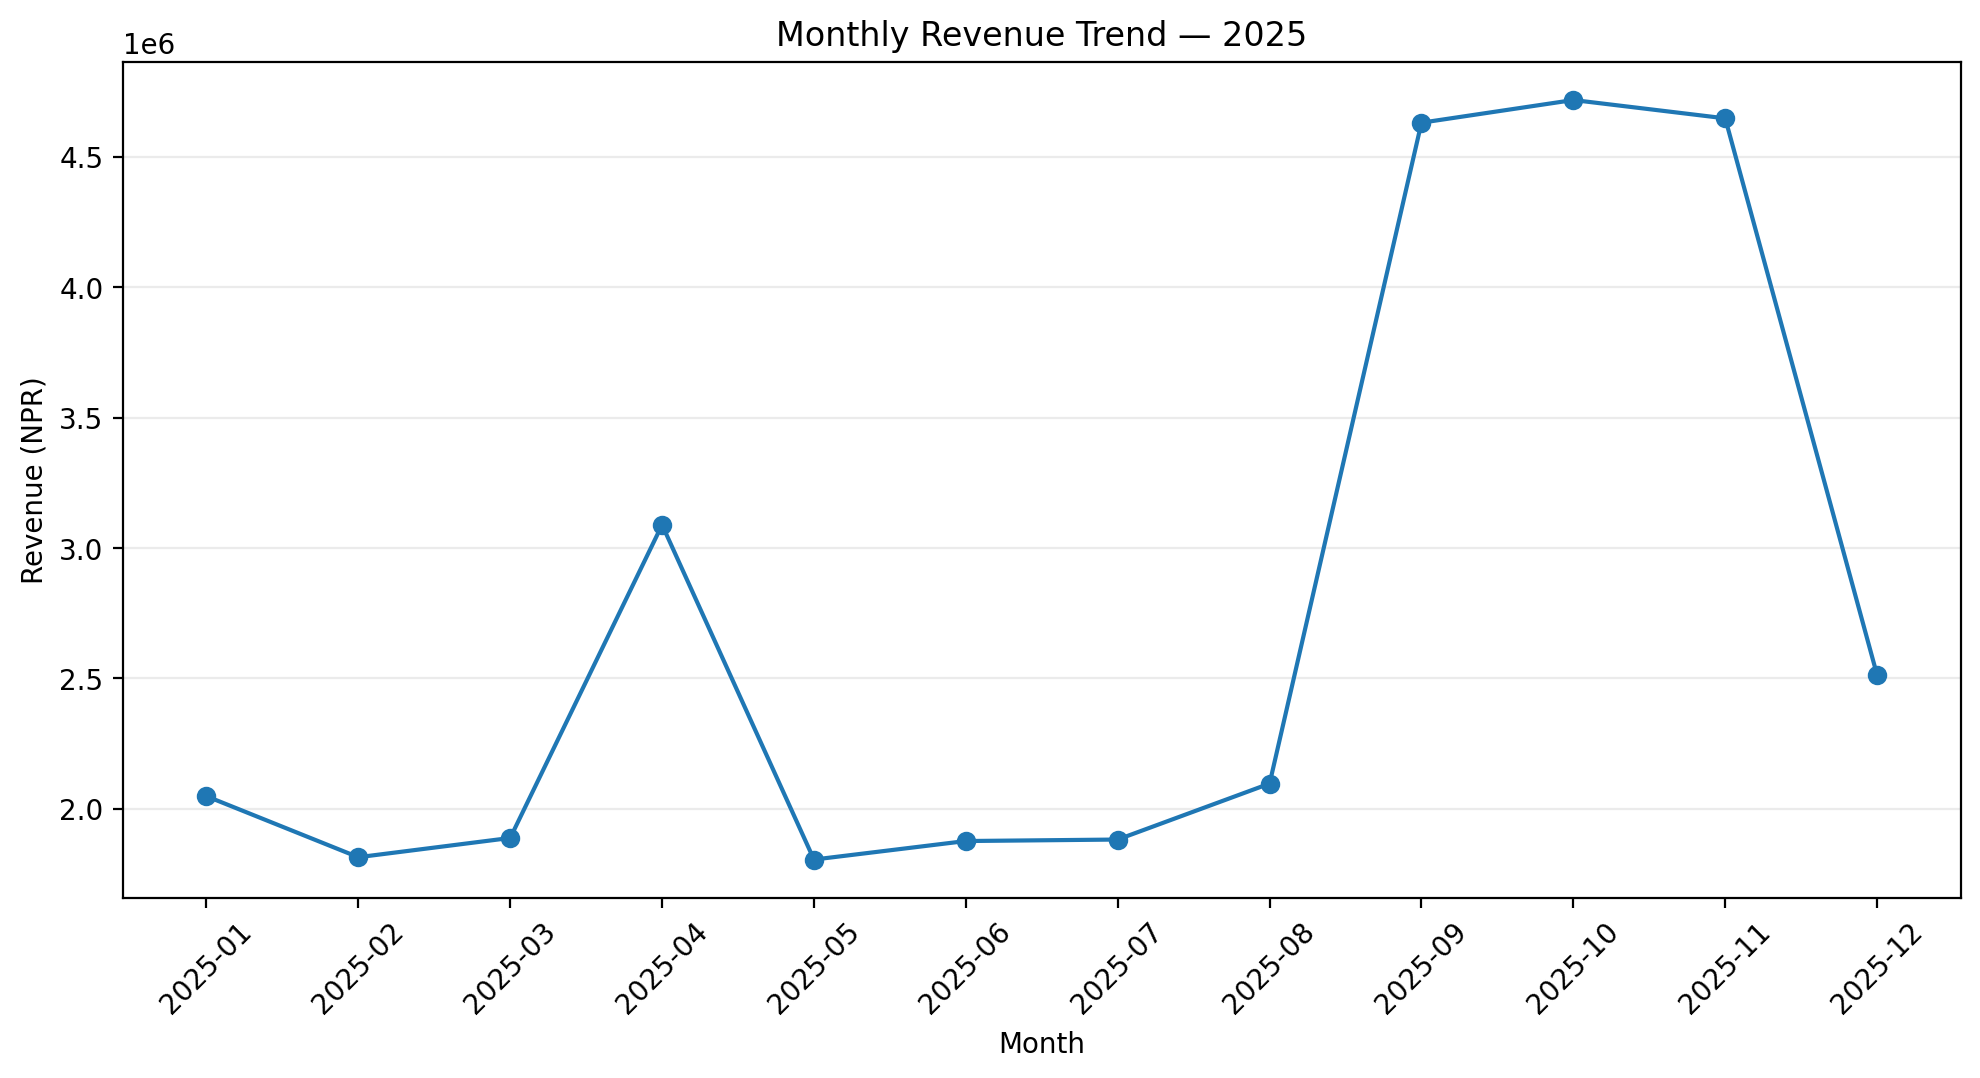

branch_revenue.png


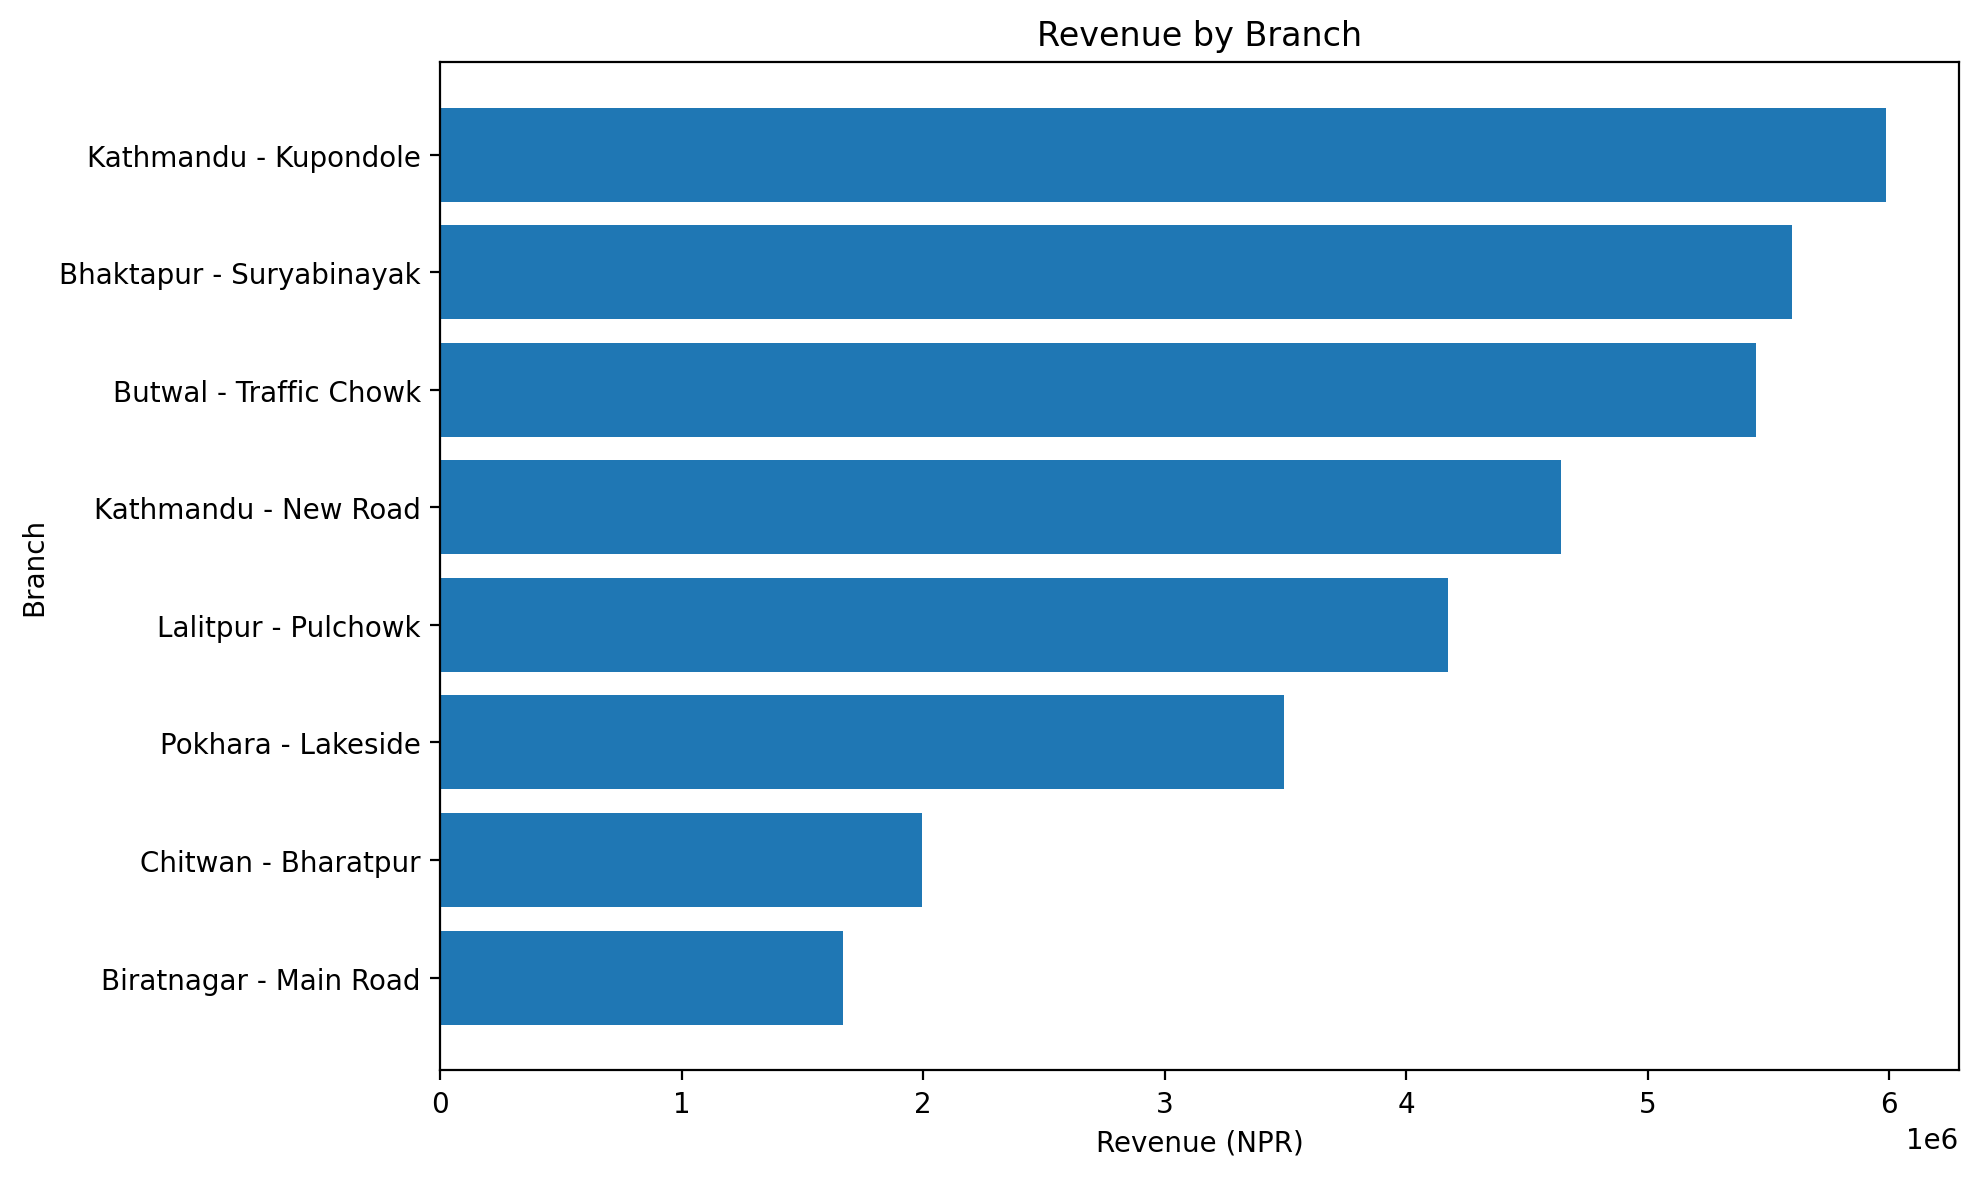

category_revenue.png


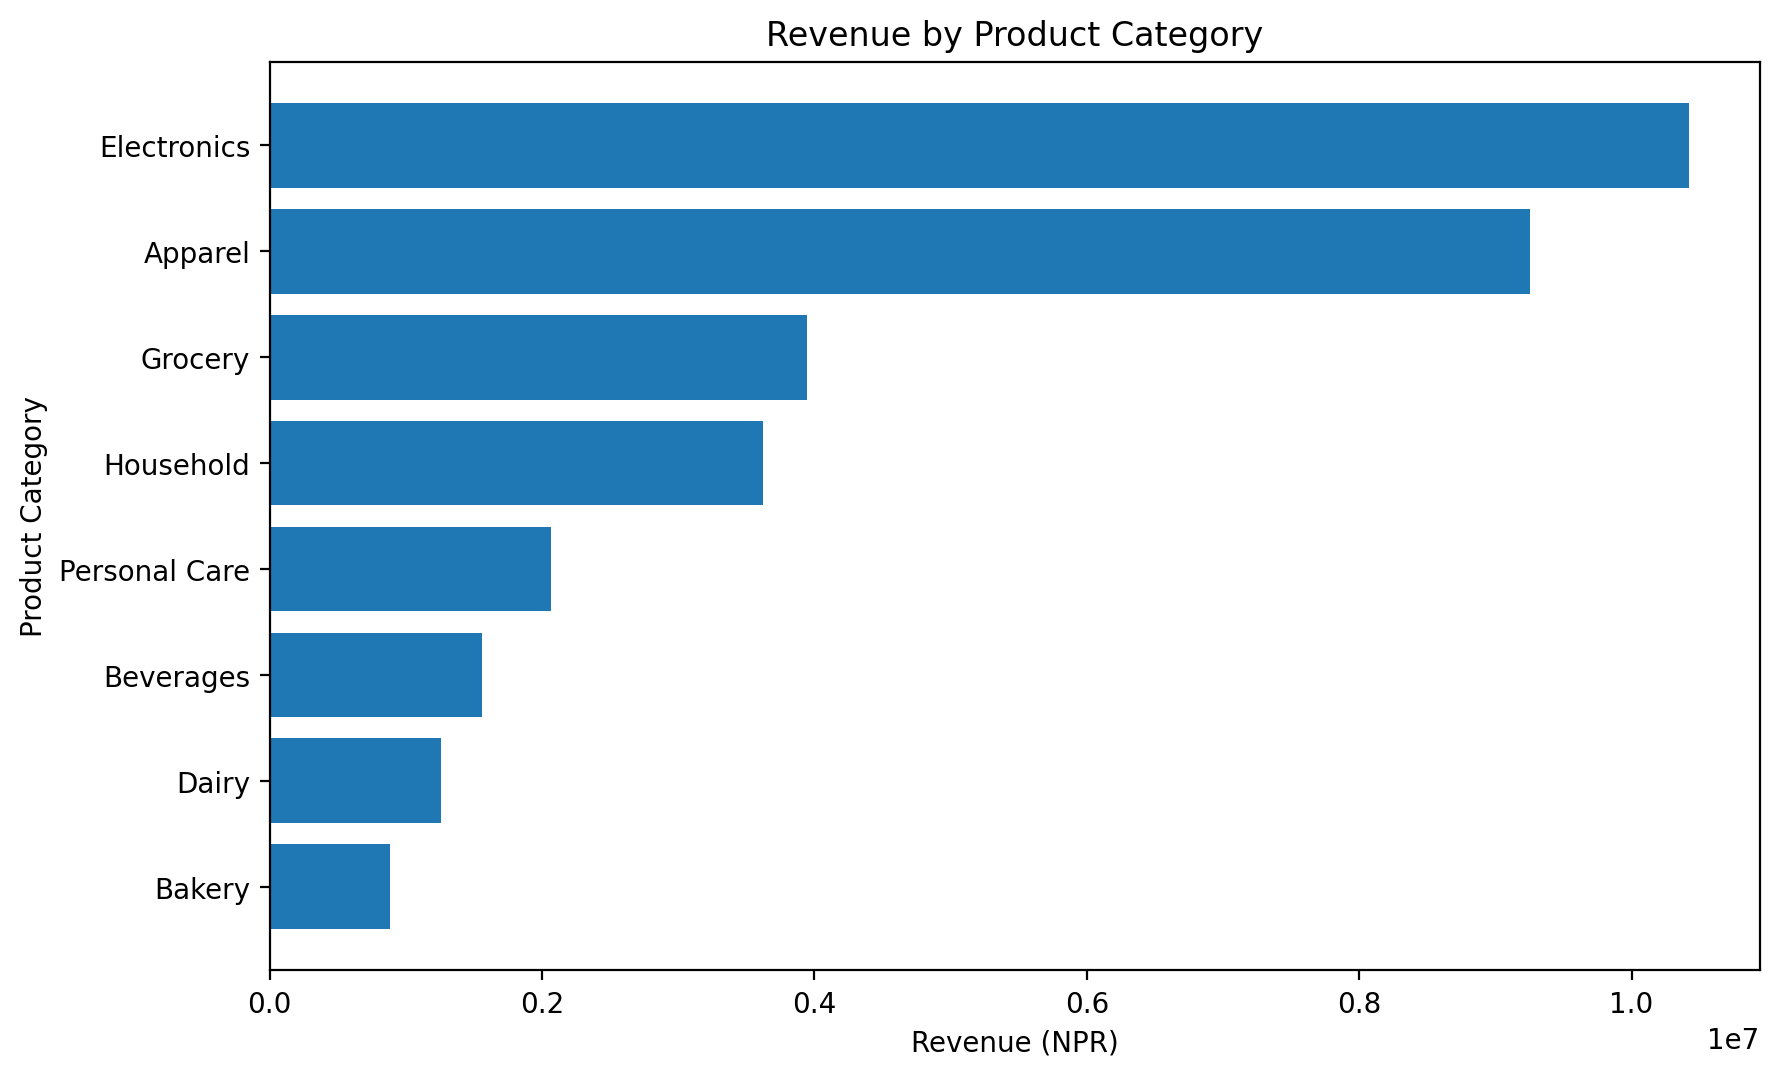

payment_method_usage.png


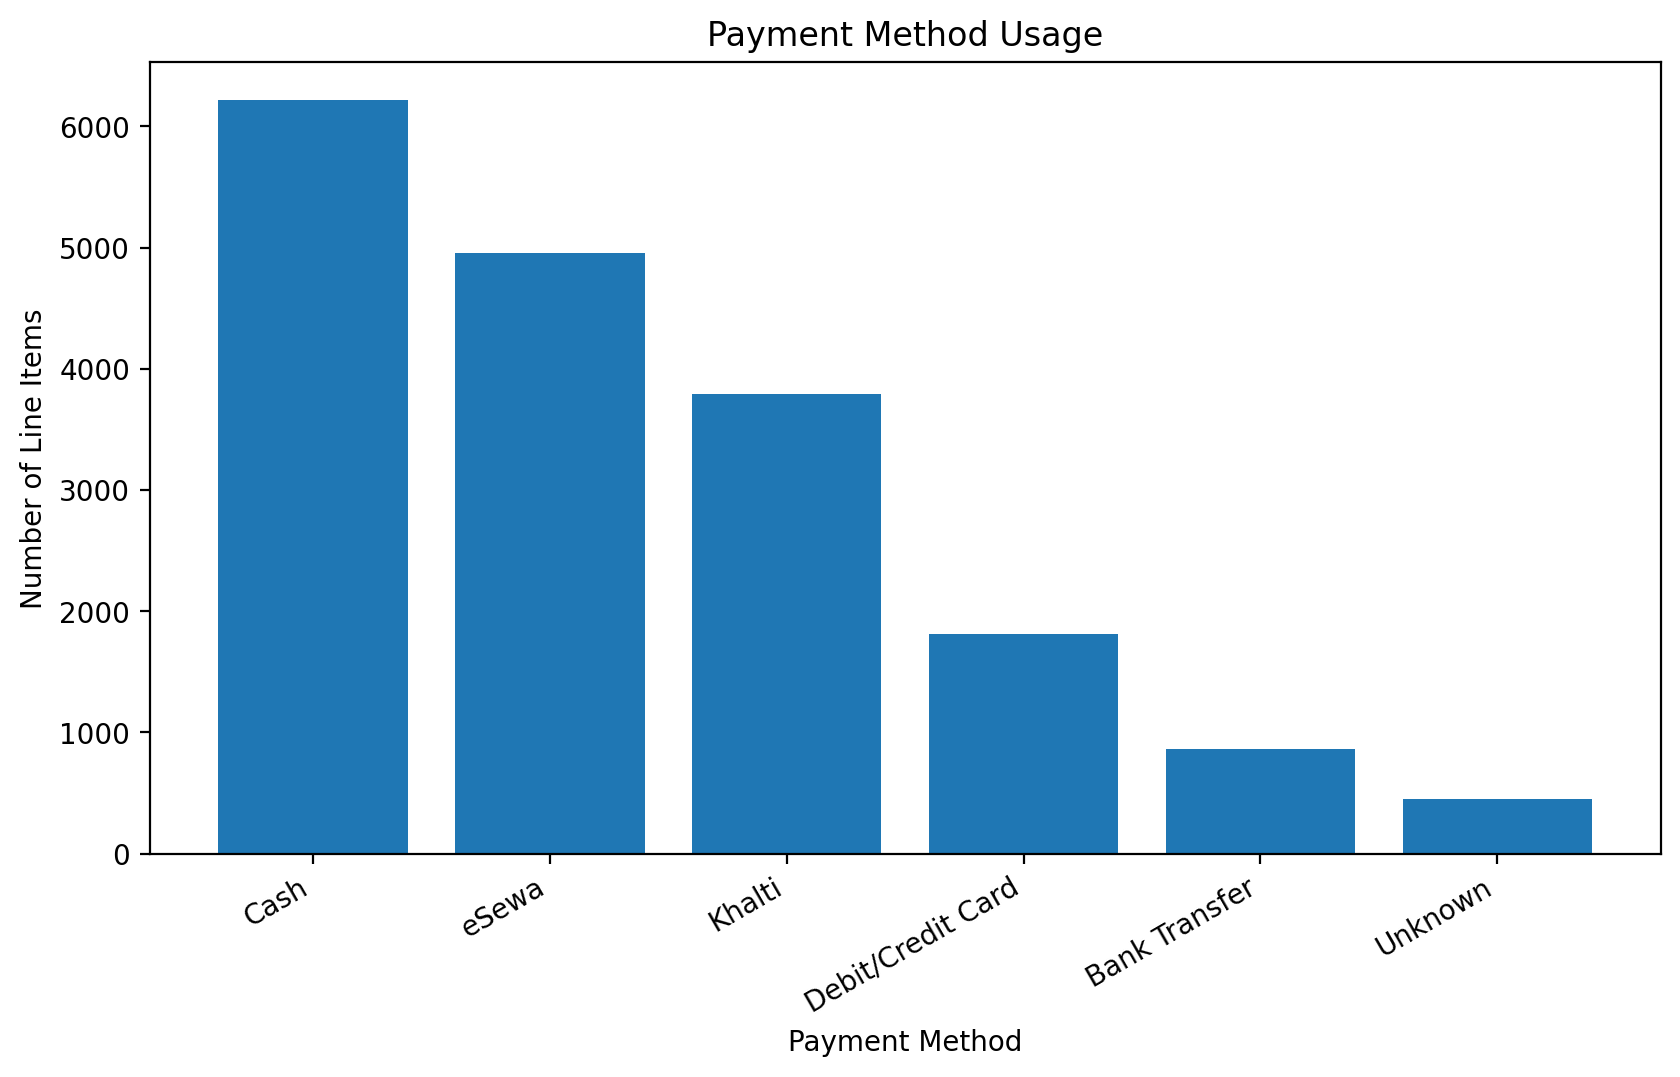

total_amount_distribution.png


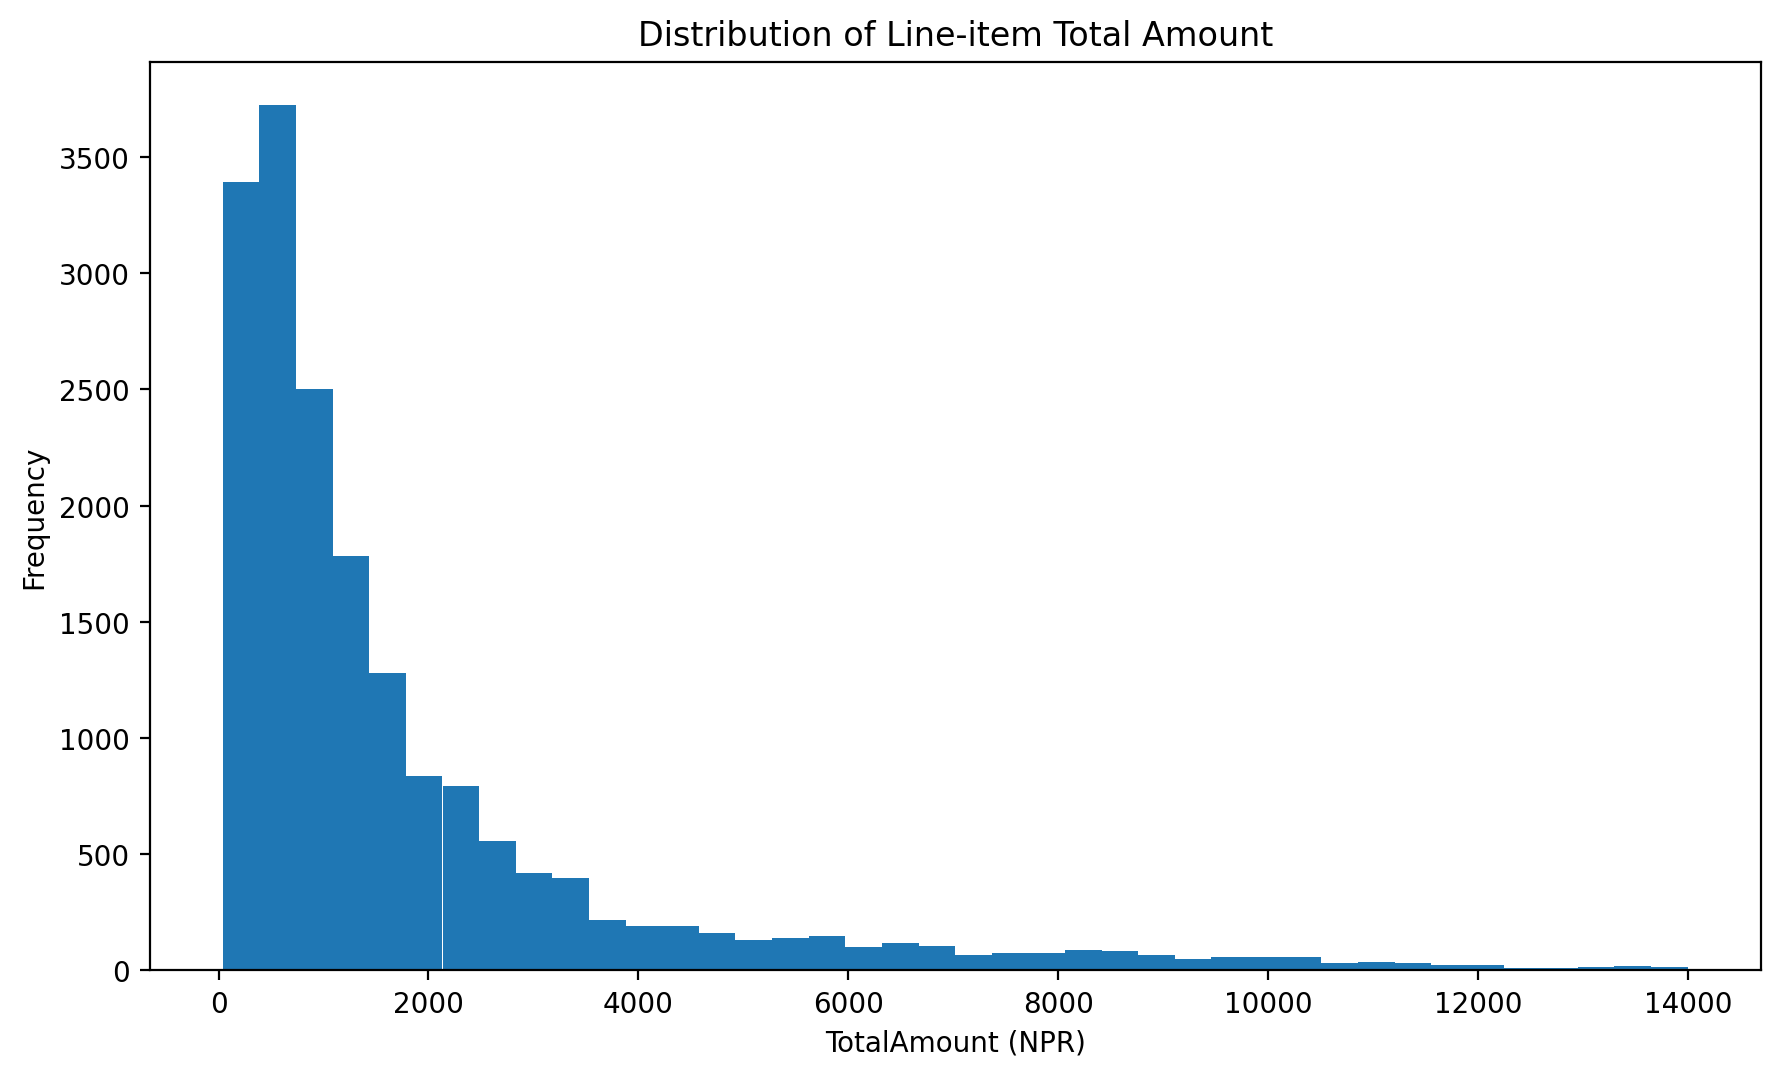

revenue_by_day.png


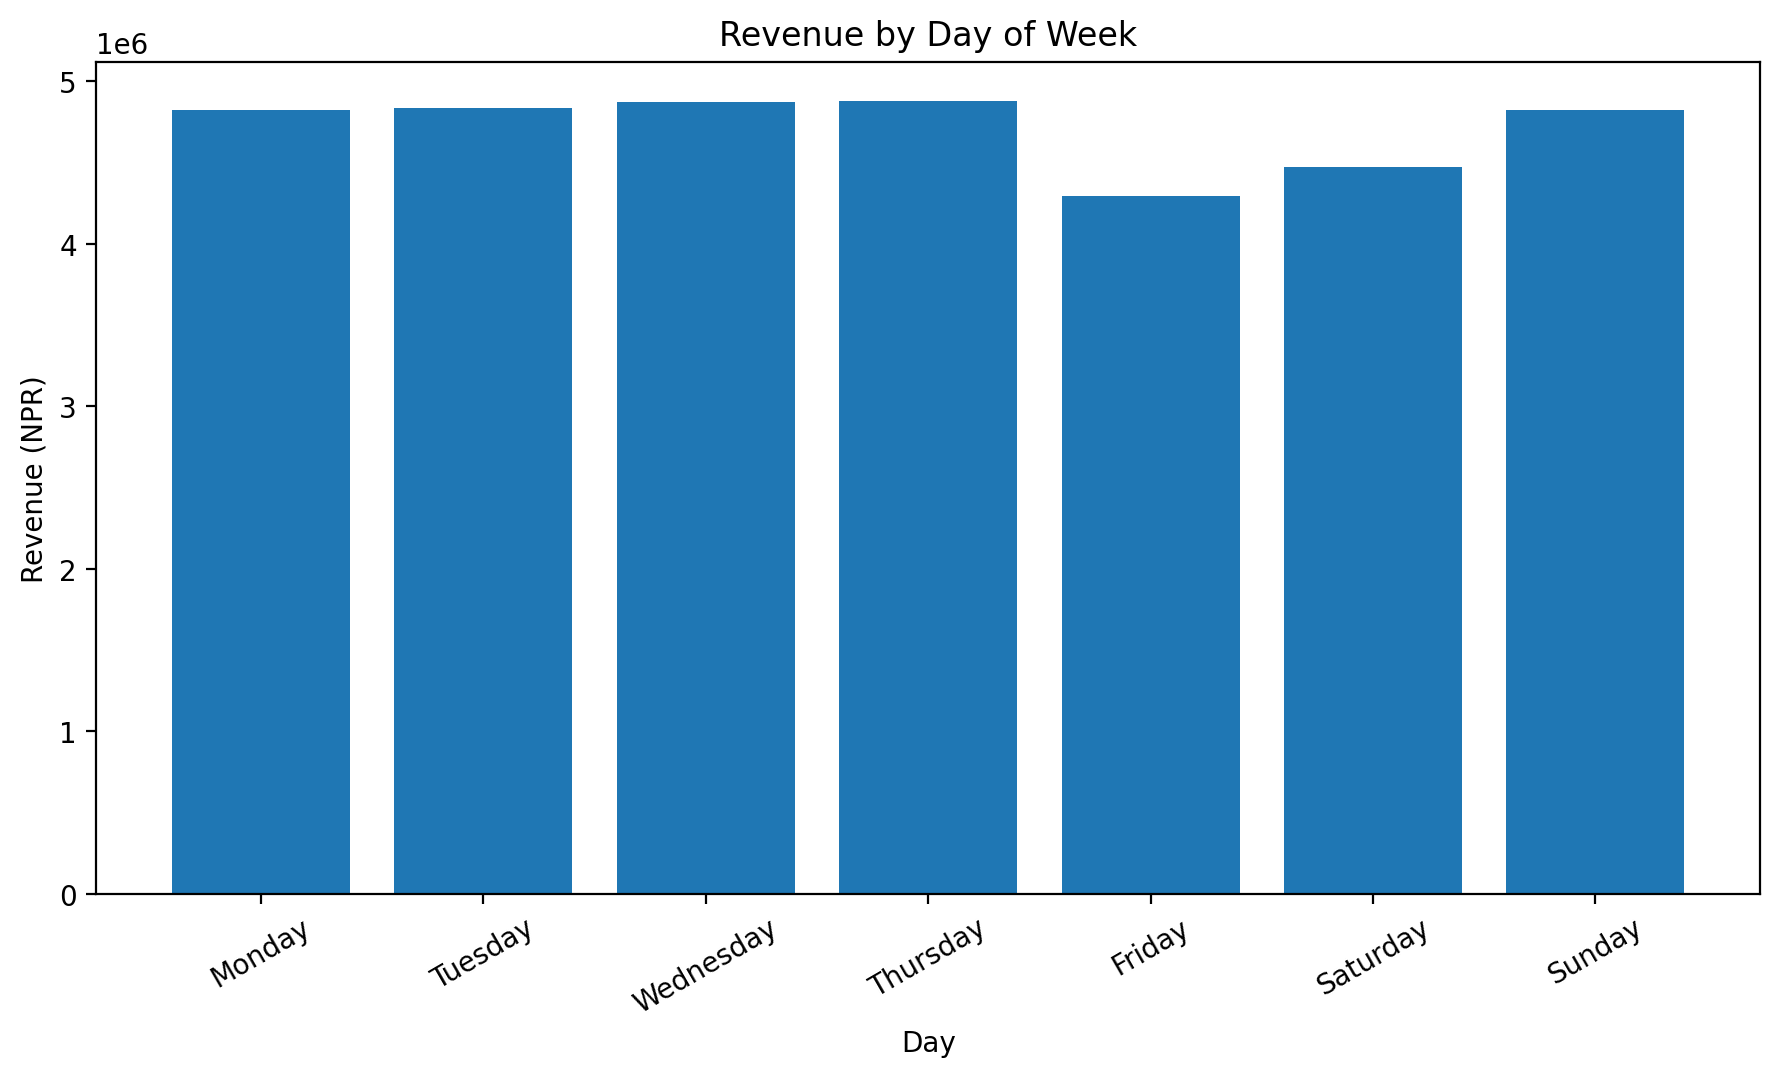

top_products_revenue.png


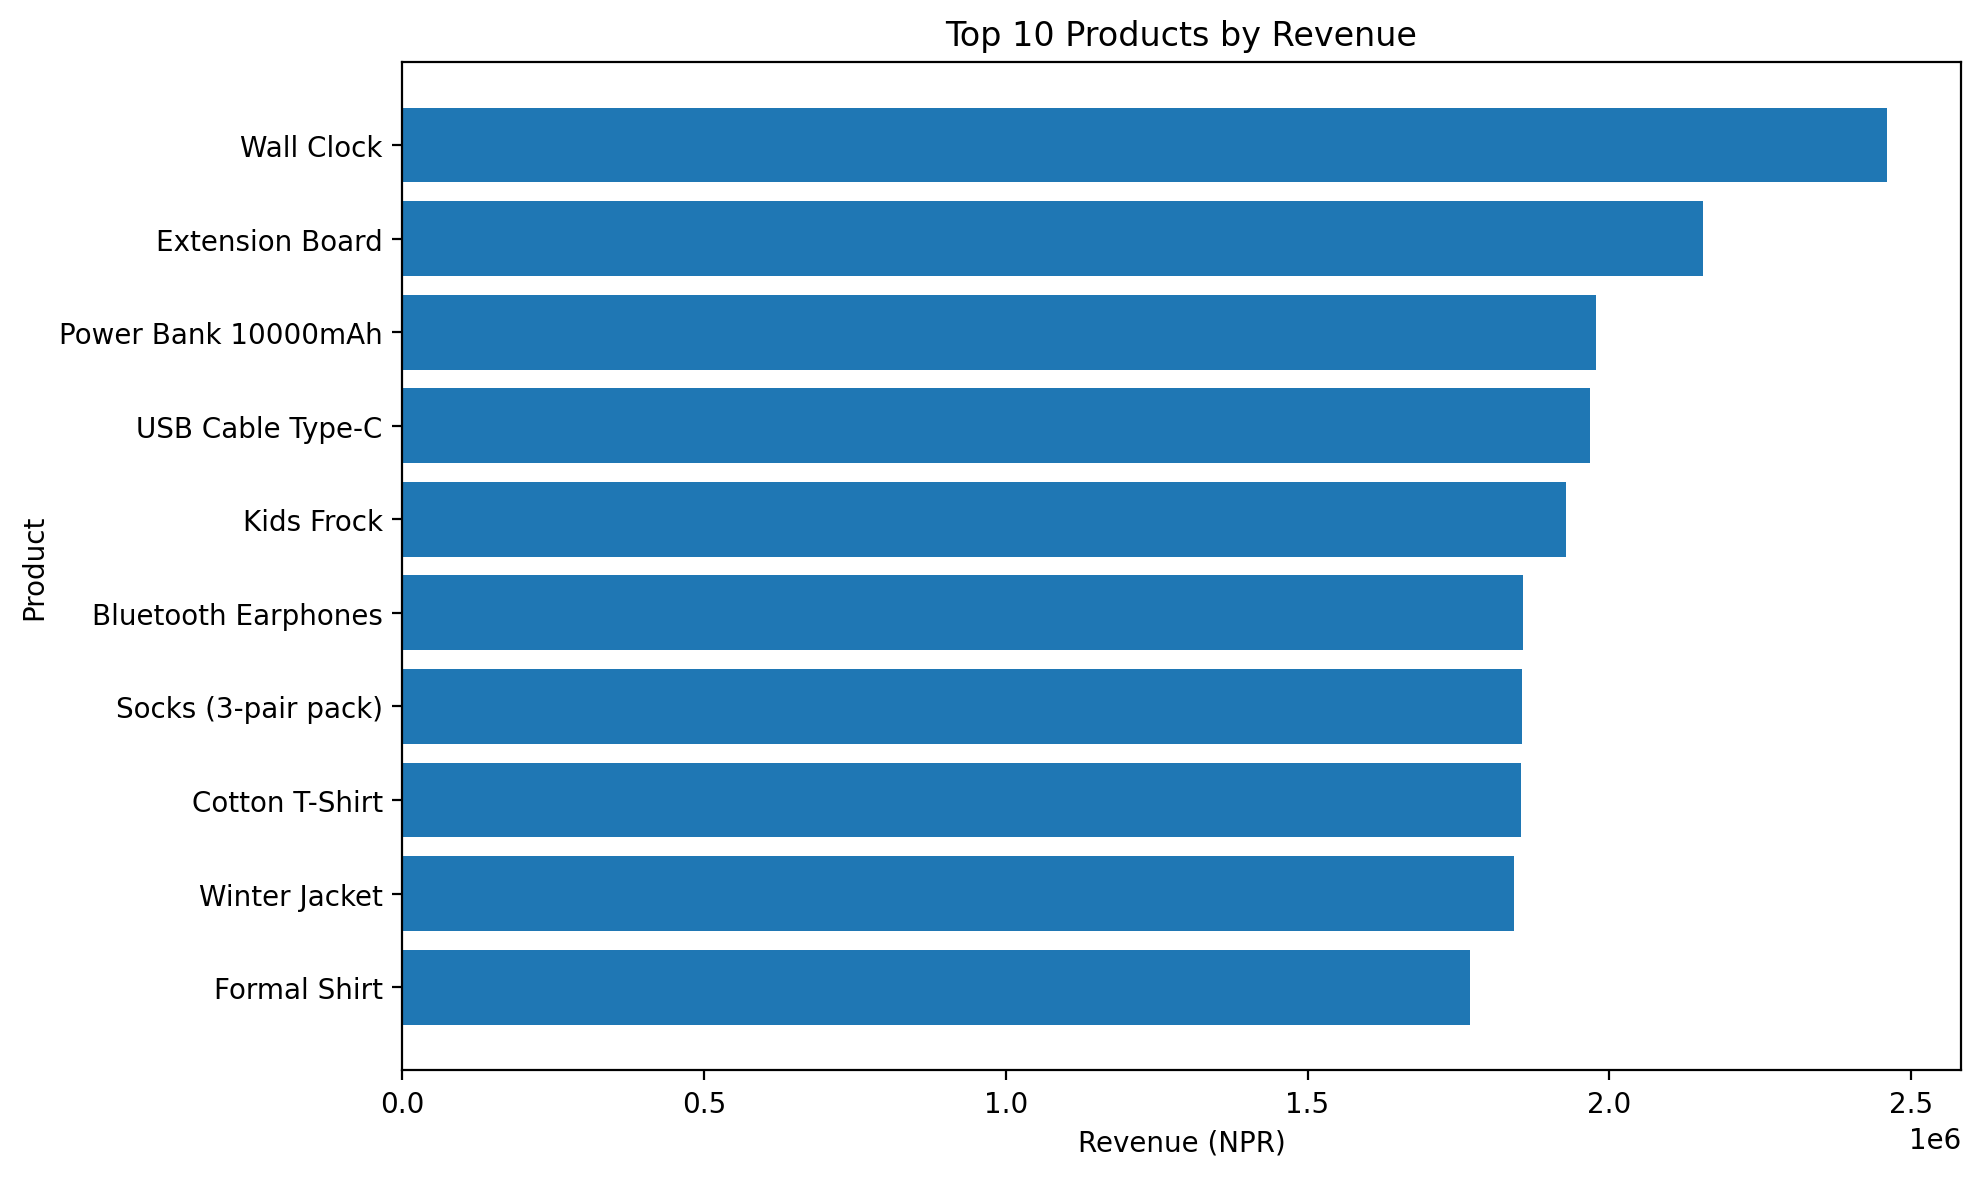

In [15]:
bscs.create_visualizations(df, tables)
from IPython.display import Image, display
for filename in [
    'monthly_revenue_trend.png',
    'branch_revenue.png',
    'category_revenue.png',
    'payment_method_usage.png',
    'total_amount_distribution.png',
    'revenue_by_day.png',
    'top_products_revenue.png',
]:
    print(filename)
    display(Image(filename=str(PROJECT_ROOT / 'images' / filename), width=800))

## Step 16 — Predictive modelling

In [16]:
model, model_metrics, feature_importance = bscs.train_model(df)
print(json.dumps(model_metrics, indent=2))
display(feature_importance.round(4))

{
  "model": "RandomForestRegressor",
  "train_rows": 14470,
  "test_rows": 3618,
  "r2": 0.99999844716491,
  "mae": 1.0984218352680413,
  "rmse": 2.7136924802961997
}


,Feature,ImportanceMean,ImportanceStd,RelativeImportancePercent
1,UnitPrice,1.76,0.03,75.64
0,Quantity,0.57,0.01,24.36
2,Branch,0.00,0.00,0.00
3,ProductCategory,0.00,0.00,0.00


### Model interpretation

The Random Forest model uses `Quantity`, `UnitPrice`, `Branch`, and `ProductCategory`. Its performance is expected to be extremely high because `TotalAmount` is mathematically determined by quantity and unit price. This makes the model useful for demonstrating preprocessing and evaluation, but not for genuine future-demand forecasting.

## Step 17 — Business insights

In [17]:
top_branch = tables['branch_summary'].iloc[0]
top_city = tables['city_summary'].iloc[0]
top_revenue_category = tables['category_summary'].iloc[0]
top_transaction_category = tables['category_summary'].sort_values('UniqueTransactions', ascending=False).iloc[0]
peak_month = tables['monthly_revenue'].loc[tables['monthly_revenue']['Revenue'].idxmax()]
low_month = tables['monthly_revenue'].loc[tables['monthly_revenue']['Revenue'].idxmin()]

print(f"1. Highest-revenue branch: {top_branch['Branch']} — NPR {top_branch['Revenue']:,.2f}")
print(f"2. Highest-revenue city: {top_city['City']} — NPR {top_city['Revenue']:,.2f}")
print(f"3. Highest-revenue category: {top_revenue_category['ProductCategory']}")
print(f"4. Most widely purchased category: {top_transaction_category['ProductCategory']}")
print(f"5. Peak month: {peak_month['YearMonth']} — NPR {peak_month['Revenue']:,.2f}")
print(f"6. Lowest month: {low_month['YearMonth']} — NPR {low_month['Revenue']:,.2f}")
print('7. Review outliers instead of automatically removing them; many may be legitimate high-value purchases.')
print('8. Add source-system validation for required fields, unique line identifiers, and controlled master data.')

1. Highest-revenue branch: Kathmandu - Kupondole — NPR 5,988,126.62
2. Highest-revenue city: Kathmandu — NPR 10,629,157.12
3. Highest-revenue category: Electronics
4. Most widely purchased category: Grocery
5. Peak month: 2025-10 — NPR 4,717,670.71
6. Lowest month: 2025-05 — NPR 1,804,819.74
7. Review outliers instead of automatically removing them; many may be legitimate high-value purchases.
8. Add source-system validation for required fields, unique line identifiers, and controlled master data.


## Export all outputs

In [18]:
bscs.export_outputs(df_raw, df, cleaning_summary, tables, model_metrics, feature_importance)
bscs.write_report(df_raw, df, cleaning_summary, tables, model_metrics, feature_importance)
print('Cleaned dataset:', PROJECT_ROOT / 'outputs' / 'BSCS_cleaned.csv')
print('Complete written answers:', PROJECT_ROOT / 'outputs' / 'analysis_report.md')

Cleaned dataset: /mnt/data/BSCS_VSCode_Project/outputs/BSCS_cleaned.csv
Complete written answers: /mnt/data/BSCS_VSCode_Project/outputs/analysis_report.md


## Step 18 — Portfolio/GitHub checklist

- [x] README explains the raw nulls and duplicate rows.
- [x] Cleaning and analysis are separated.
- [x] Before/after data-quality summaries are exported.
- [x] Seven visualisations are saved in `/images`.
- [x] Clean GitHub-ready folders are included: `/data`, `/notebooks`, `/images`, `/outputs`, and `/src`.